# 10 — Block filters: a VECM on nominal and real yields

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/10_block_filters_vecm.ipynb)

Variables observed in levels can share a long-run relation: the nominal 10-year
Treasury yield and the 10-year TIPS real yield move together, their difference,
the breakeven inflation, staying in a range. A vector error-correction model
(VECM) filters such a block jointly. Its standardized innovations join the
residual layer next to the assets, the C-vine carries the dependence between
all of them, and the paths of the block come back in levels from the last
observed values through the model's own recursion. Needs `statsmodels`.

Runtime: about 4 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git[garch,blocks]"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

for pkg in ("arch", "statsmodels"):
    try:
        __import__(pkg)
    except ImportError:
        import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
from cvinemarketgen import load_fred_monthly, load_etf_monthly, Targets, CVineMarket, BlockVECM, iid_tests

cvinemarketgen 0.3.0


## Load the block and one asset

Monthly averages of the daily FRED series DGS10 (nominal 10-year yield) and DFII10 (10-year TIPS real yield), in percent: for month $t$ with $n_t$ trading days, $x_t = \frac{1}{n_t}\sum_{d \in t} y_d$, so the block is $\mathbf x_t = (x_{1t}, x_{2t})'$ in levels. Next to it the monthly return of SPY from the ETF loader of notebook 08, $r_t = P_t / P_{t-1} - 1$ on adjusted closes, aligned on the common months. Cached in `data/fred_cache.csv`. The table shows the last rows; the yields are levels, SPY a return, and the market will treat them differently: the block is filtered in levels, SPY by its own model.

In [2]:
yields = load_fred_monthly(["DGS10", "DFII10"], start="2003-01", cache=os.path.join(ROOT, "data", "fred_cache.csv"))
spy = load_etf_monthly(["SPY"], cache=os.path.join(ROOT, "data", "etf_cache.csv"))
data = yields.join(spy, how="inner")
print(data.shape[0], "months,", data.index.min(), "to", data.index.max())
data.tail()

FRED series read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/fred_cache.csv: 285 months, 2003-01 to 2026-09
ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache.csv: 232 months, 2007-06 to 2026-09
232 months, 2007-06 to 2026-09


,DGS10,DFII10,SPY
month,,,
2026-05,4.484000,2.039000,0.052626
2026-06,4.470476,2.179048,-0.010293
2026-07,4.599545,2.353182,0.000348
2026-08,4.684286,2.397143,0.026799
2026-09,4.877273,2.516364,-0.003598


The two yields and their difference, the breakeven inflation $b_t = x_{1t} - x_{2t}$: by the Fisher relation the nominal yield is the real yield plus expected inflation (and premia), so the difference is the market's inflation compensation. Each yield wanders like a random walk over the sample; the difference stays in a range. That is the visual form of one cointegrating relation among two integrated series.

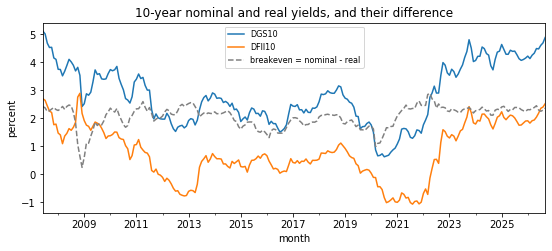

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
data[["DGS10", "DFII10"]].plot(ax=ax); (data["DGS10"] - data["DFII10"]).rename("breakeven = nominal - real").plot(ax=ax, ls="--", color="grey")
ax.set_ylabel("percent"); ax.set_title("10-year nominal and real yields, and their difference"); ax.legend(fontsize=8); plt.show()

## Rank and lags

The vector error-correction model for the $p = 2$ yields with $q$ lagged differences is

$$
\Delta \mathbf x_t = \mathbf c + \boldsymbol\alpha\, \boldsymbol\beta' \mathbf x_{t-1} + \sum_{i=1}^{q} \boldsymbol\Gamma_i\, \Delta \mathbf x_{t-i} + \boldsymbol\eta_t,
$$

where $\boldsymbol\beta$ ($p \times r$) holds the $r$ cointegrating vectors, $\boldsymbol\beta' \mathbf x_t$ the $r$ stationary combinations, $\boldsymbol\alpha$ ($p \times r$) the adjustment of each variable to them, and $\boldsymbol\Pi = \boldsymbol\alpha\boldsymbol\beta'$ has rank $r$. The Johansen trace test decides $r$: with $\hat\lambda_1 \ge \dots \ge \hat\lambda_p$ the eigenvalues of the reduced-rank regression, the statistic for the hypothesis of at most $r$ relations is

$$
\mathrm{trace}(r) = -T \sum_{i=r+1}^{p} \ln(1 - \hat\lambda_i),
$$

compared with its 5 percent critical value; the rank is the first $r$ for which the test does not reject, starting from $r = 0$. The result depends on $q$: with one lag it marginally rejects a second unit root (the block would be a stationary VAR in levels), with two lags, the usual choice on monthly data, it finds exactly one relation. The notebook fixes two lags and lets the rank be tested. Read the table row by row: `trace, r = 0` above its critical value rejects "no relation"; `trace, r <= 1` below its critical value accepts one.

In [4]:
from statsmodels.tsa.vector_ar.vecm import select_coint_rank
rows = {}
for q in (1, 2):
    r = select_coint_rank(data[["DGS10", "DFII10"]].values, det_order=0, k_ar_diff=q, method="trace", signif=0.05)
    rows[f"q = {q}"] = {"trace, r = 0": r.test_stats[0], "critical 5%": r.crit_vals[0], "trace, r <= 1": r.test_stats[1], "critical 5% ": r.crit_vals[1], "rank": r.rank}
pd.DataFrame(rows).T.round(2)

,"trace, r = 0",critical 5%,"trace, r <= 1",critical 5%,rank
q = 1,24.60,15.49,4.10,3.84,2.0
q = 2,22.19,15.49,2.51,3.84,1.0


`BlockVECM` estimates the model by Johansen's reduced-rank maximum likelihood (statsmodels), with the constant inside the model and $r$ from the trace test when it is not given. The cointegrating vector is normalized on the first variable, $\boldsymbol\beta = (1, \beta_2)'$; $\boldsymbol\alpha$ gives how much each yield moves next month per unit of the deviation $\boldsymbol\beta' \mathbf x_{t-1}$; $\sigma_k$ is the standard deviation of the $k$-th innovation $\eta_{k,t}$. The parameter count is $2pr - r^2$ for $\boldsymbol\alpha$ and $\boldsymbol\beta$ net of the normalizations, $p^2 q$ for the $\boldsymbol\Gamma_i$, $p$ for the constant and $p$ for the variances, and $\mathrm{BIC} = k \ln T - 2\ell$ with $\ell$ the Gaussian log-likelihood. The BIC is on the block's own scale (levels in percent); it compares blocks with each other, not with the univariate models of the assets.

In [5]:
m = BlockVECM(lags=2).fit(data[["DGS10", "DFII10"]])
print(m.name, "| n_params", m.n_params, "| BIC", round(m.bic, 1))
pd.DataFrame({"cointegrating vector (beta)": m.beta[:, 0], "adjustment (alpha)": m.alpha[:, 0], "innovation sd (sigma)": m.sigma}, index=m.columns).round(3)

VECM(r=1, q=2) | n_params 15 | BIC -386.0


,cointegrating vector (beta),adjustment (alpha),innovation sd (sigma)
DGS10,1.000,0.034,0.196
DFII10,-1.071,0.110,0.172


The cointegrating vector, normalized on the nominal yield, is close to
(1, −1): the stationary combination is the breakeven. The real yield carries
most of the adjustment, so when the breakeven drifts from its mean it is the
real yield that moves back.

## The residual layer of the block

`filter()` gives the standardized innovations, $\varepsilon_{k,t} = \hat\eta_{k,t} / \sigma_k$, one column per variable: each innovation divided by its own standard deviation and nothing else. They are the block's contribution to the residual layer, tested for independence over time like any other residual, with the Ljung-Box statistic $Q_m = n(n+2)\sum_{j \le m} \hat\rho_j^{\,2}/(n-j) \sim \chi^2_m$ on $\varepsilon_{k,t}$ and on $\varepsilon_{k,t}^2$, and the ARCH-LM statistic $n R^2$ of $\varepsilon_{k,t}^2$ on its $m = 20$ lags; the table gives the p-values per variable. The correlation between the two columns is what the vine will carry; the VECM's own covariance matrix $\Sigma_\eta = \mathbf D \mathbf R \mathbf D$, with $\mathbf D = \mathrm{diag}(\sigma_k)$ and $\mathbf R$ the correlation matrix, is not used beyond $\mathbf D$.

In [6]:
z = m.filter()
pd.DataFrame({c: iid_tests(z[c].values) for c in z.columns}).round(3)

,DGS10,DFII10
lb_z,0.934,0.824
lb_z2,0.982,0.844
arch_lm,0.845,0.210


The correlation matrix $\mathbf R$ of the standardized innovations. The nominal and real innovations are strongly positively correlated: most monthly news moves both yields. In the market this correlation is a target of the vine's calibration, together with the correlations with SPY's residual; the copula family chosen for the pair decides how the two co-move in the tails, which a correlation does not say.

In [7]:
z.corr().round(2)

,DGS10,DFII10
DGS10,1.00,0.78
DFII10,0.78,1.00


## The block inside a market

A tuple key gives the block; `'vecm(q=2)'` fixes the lags and tests the rank. The residual layer of the market has three columns, $\varepsilon_{1,t}$ and $\varepsilon_{2,t}$ from the block and the standardized residual of SPY's AR(1)-GARCH(1,1), $r_t = c + \phi r_{t-1} + \sigma_t \varepsilon_{3,t}$ with $\sigma_t^2 = \omega + a\,\epsilon_{t-1}^2 + b\,\sigma_{t-1}^2$. The targets of the generator are the sample moments of these three columns, mean, volatility, skewness and kurtosis per column and their $3 \times 3$ correlation matrix $\Sigma^*$, with the kurtosis floored at $3.1 + 2\gamma_1^2$ where it falls below the Johnson SU boundary; the families are selected on them by the exceedance-correlation signatures, the C-vine is calibrated to $\Sigma^*$, and `dynamics_report` lists the model per variable with its parameter count and BIC (the block's row is repeated for each of its variables).

In [8]:
t = Targets.from_history(data)
t0 = time.time()
cv = CVineMarket(t, central="SPY", families="auto", dynamics={("DGS10", "DFII10"): "vecm(q=2)", "SPY": "ar1-garch"}).fit()
print(f"fit: {time.time() - t0:.0f} s")
cv.dynamics_report

fit: 90 s


,model,n_params,loglik,bic
DGS10,"VECM(r=1, q=2)",15,233.773249,-386.040667
DFII10,"VECM(r=1, q=2)",15,233.773249,-386.040667
SPY,"AR(1)-GARCH(1,1)",5,407.660703,-788.109318


The edges of the C-vine on the residual layer, SPY as the central node: tree 1 has the two pairs with SPY, tree 2 the pair of yield innovations conditional on SPY, each with its family, rotation and calibrated parameter. For a Gumbel with parameter $\theta$ the upper-tail coefficient is $\lambda_U = 2 - 2^{1/\theta}$, for a Clayton the lower-tail coefficient is $\lambda_L = 2^{-1/\theta}$, and a rotation moves the tail to the other corners; a mixture $w C_1 + (1-w) C_2$ appears when the exceedance curve changes sign.

In [9]:
cv.edges

,tree,edge,selected family,parameters
0,1,"DGS10 , SPY",gaussian 0°,theta=0.085
1,1,"DFII10 , SPY",clayton 270° + gumbel 0°,"w=0.62, theta=(0.450, 1.107)"
2,2,"DFII10 , DGS10 | SPY",gaussian 0°,theta=0.836


## Paths in levels from the last curve

`simulate_paths` draws $1{,}000 \times 24$ residual vectors from the calibrated vine (one cross-section, reshaped into paths) and pushes the block's two columns through the inverse of the filter, the VECM recursion started from the last $q + 1 = 3$ observed months. For each path and month $t = 1, \dots, 24$,

$$
\mathbf x_t = \mathbf x_{t-1} + \mathbf c + \boldsymbol\alpha\boldsymbol\beta' \mathbf x_{t-1} + \sum_{i=1}^{q} \boldsymbol\Gamma_i\, \Delta \mathbf x_{t-i} + \mathbf D\, \boldsymbol\varepsilon_t,
$$

with $\mathbf D = \mathrm{diag}(\sigma_1, \sigma_2)$ and $\boldsymbol\varepsilon_t$ the vine's draw for the two block columns; the first months use the observed lagged differences. The yields come back in percent, SPY in returns through its own inverse. The fan shows the quantiles $q_\alpha(t)$ of the 10-year yield across paths at each month, $\alpha \in \{0.05, 0.25, 0.5, 0.75, 0.95\}$, and the table the 5, 50 and 95 percent quantiles of both yields at months 1, 12 and 24.

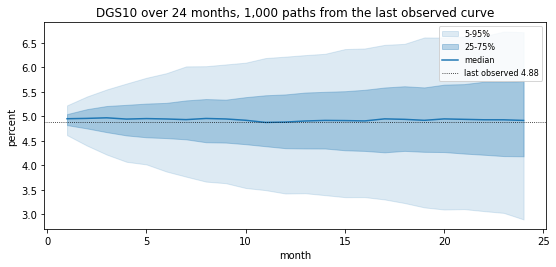

DGS10             DFII10            
    0.05  0.50  0.95   0.05  0.50  0.95
t                                      
1   4.62  4.95  5.22   2.34  2.55  2.86
12  3.43  4.88  6.22   1.53  2.67  3.77
24  2.90  4.92  6.72   1.14  2.71  4.23

In [10]:
P = cv.simulate_paths(1000, 24, seed=1)
last = data.iloc[-1]
j = P.assets.index("DGS10"); q = np.quantile(P.array[:, :, j], [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.fill_between(range(1, 25), q[0], q[4], color="tab:blue", alpha=0.15, label="5-95%"); ax.fill_between(range(1, 25), q[1], q[3], color="tab:blue", alpha=0.3, label="25-75%")
ax.plot(range(1, 25), q[2], color="tab:blue", label="median"); ax.axhline(last["DGS10"], color="black", lw=0.8, ls=":", label=f"last observed {last['DGS10']:.2f}")
ax.set_xlabel("month"); ax.set_ylabel("percent"); ax.set_title("DGS10 over 24 months, 1,000 paths from the last observed curve"); ax.legend(fontsize=8); plt.show()
P.to_frame().groupby("t")[["DGS10", "DFII10"]].quantile([0.05, 0.5, 0.95]).unstack().round(2).loc[[1, 12, 24]]

## The breakeven stays anchored

Multiply the VECM by $\boldsymbol\beta'$: the stationary combination $b_t = \boldsymbol\beta' \mathbf x_t$ follows

$$
b_t = \boldsymbol\beta' \mathbf c + (1 + \boldsymbol\beta'\boldsymbol\alpha)\, b_{t-1} + \boldsymbol\beta' \sum_i \boldsymbol\Gamma_i \Delta \mathbf x_{t-i} + \boldsymbol\beta' \boldsymbol\eta_t,
$$

an autoregression with coefficient $1 + \boldsymbol\beta'\boldsymbol\alpha$, which is below one in absolute value when the adjustment $\boldsymbol\alpha$ pulls the right way; its variance along the paths converges to a finite value instead of growing with the horizon. With $\boldsymbol\beta \approx (1, -1)'$ the combination is the breakeven itself. The table compares the mean and standard deviation of the simulated breakeven across paths at months 1, 12 and 24 with the historical mean and standard deviation of $x_{1t} - x_{2t}$: the dispersion at month 24 is of the order of the historical one, whereas two random walks would let it wander with a standard deviation growing like $\sqrt{t}$.

In [11]:
be = P.array[:, :, P.assets.index("DGS10")] - P.array[:, :, P.assets.index("DFII10")]
hist_be = data["DGS10"] - data["DFII10"]
pd.DataFrame({"history": [hist_be.mean(), hist_be.std()], "paths, month 1": [be[:, 0].mean(), be[:, 0].std()],
              "paths, month 12": [be[:, 11].mean(), be[:, 11].std()], "paths, month 24": [be[:, 23].mean(), be[:, 23].std()]},
             index=["breakeven mean", "breakeven sd"]).round(3)

,history,"paths, month 1","paths, month 12","paths, month 24"
breakeven mean,2.056,2.366,2.210,2.203
breakeven sd,0.391,0.134,0.386,0.397


## Without the block: two univariate AR(1) filters

Filtering each yield on its own with an AR(1) on the level, $x_{kt} = c_k + \phi_k x_{k,t-1} + \sigma_k \varepsilon_{kt}$ (fitted by maximum likelihood with constant variance), ignores the long-run relation. Each yield then reverts to its own sample mean $c_k / (1 - \phi_k)$ at the rate $1 - \phi_k$ per month, and the paths of the difference have variance

$$
\mathrm{Var}(x_{1t} - x_{2t}) = \sum_{k} \sigma_k^2 \frac{1 - \phi_k^{2t}}{1 - \phi_k^2} - 2\rho\,\sigma_1 \sigma_2 \frac{1 - (\phi_1\phi_2)^t}{1 - \phi_1\phi_2},
$$

with $\rho$ the residual correlation the vine reproduces: nothing in it pulls the difference back, and with $\phi_k$ near one it grows with the horizon almost like a random walk's. The table compares the standard deviation of the breakeven at months 1, 12 and 24 under the block and under the two AR(1) filters, against the history.

In [12]:
cv1 = CVineMarket(t, central="SPY", families="auto", dynamics={"DGS10": "ar1", "DFII10": "ar1", "SPY": "ar1-garch"}).fit()
P1 = cv1.simulate_paths(1000, 24, seed=1)
be1 = P1.array[:, :, P1.assets.index("DGS10")] - P1.array[:, :, P1.assets.index("DFII10")]
pd.DataFrame({"VECM block": [be[:, 0].std(), be[:, 11].std(), be[:, 23].std()], "AR(1) filters": [be1[:, 0].std(), be1[:, 11].std(), be1[:, 23].std()], "history": [hist_be.std()] * 3},
             index=["breakeven sd, month 1", "breakeven sd, month 12", "breakeven sd, month 24"]).round(3)

,VECM block,AR(1) filters,history
"breakeven sd, month 1",0.134,0.141,0.391
"breakeven sd, month 12",0.386,0.429,0.391
"breakeven sd, month 24",0.397,0.533,0.391


The residual correlation matrices $\Sigma^*$ of the two markets. Under the block the correlation between the yield innovations is that of the VECM's $\boldsymbol\eta_t$; under the AR(1) filters it is that of two near-random-walk innovations, which is close to the correlation of the monthly changes. Both markets reproduce their own $\Sigma^*$; what differs is the recursion that turns the same kind of residual into levels.

In [13]:
print("residual correlations, VECM block:"); print(cv.fit_targets.corr.round(2))
print("residual correlations, AR(1) filters:"); print(cv1.fit_targets.corr.round(2))

residual correlations, VECM block:
         SPY  DGS10  DFII10
SPY     1.00   0.08   -0.14
DGS10   0.08   1.00    0.78
DFII10 -0.14   0.78    1.00
residual correlations, AR(1) filters:
         SPY  DGS10  DFII10
SPY     1.00   0.10   -0.13
DGS10   0.10   1.00    0.76
DFII10 -0.13   0.76    1.00


## Save

`save` writes the fitted market to JSON: the targets of the residual layer, the Johnson SU parameters $(\gamma_i, \xi_i, \delta_i, \lambda_i)$ per column, the vine's edges with their calibrated parameters, and the block with $\boldsymbol\alpha, \boldsymbol\beta, \boldsymbol\Gamma_i, \mathbf c, \boldsymbol\sigma$ and its state, the last $q + 1$ observed rows. `load` rebuilds it without refitting, so the same paths can be drawn later from the same last observed curve.

In [14]:
cv.save("block_market.json")
CVineMarket.load("block_market.json").simulate_paths(3, 6, seed=2)

Paths(n_paths=3, horizon=6, assets=3, returns)

## Where to go next

Any block goes in the same way, `'vecm'` with the rank and lags left to the
tests, or `'var'` for a block without long-run relations. The exchange-rate
notebook builds on this one: there the block's variables become the parents of
a structural equation.